Libraries imported
Dataset Loaded
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Dataset Shape:
(150, 5)

Features:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6

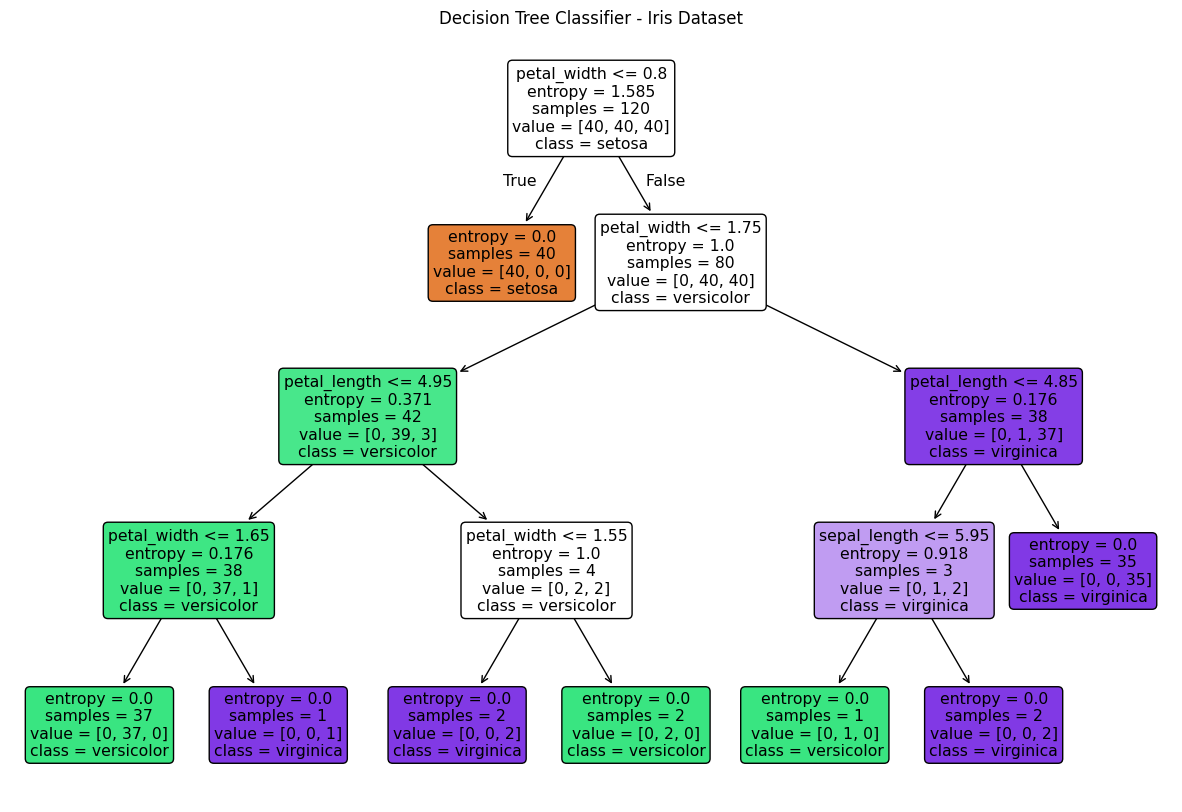

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import plot_tree

print("Libraries imported")

dataset = pd.read_csv("/content/iris.csv")

print("Dataset Loaded")
print(dataset.head())

print("\nDataset Information:")
print(dataset.info())

print("\nDataset Shape:")
print(dataset.shape)


dataset.columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species'
]

X = dataset.iloc[:, [0, 1, 2, 3]].values
y = dataset.iloc[:, -1].values

print("\nFeatures:")
print(X[:5])

print("\nTarget:")
print(y[:5])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

classifier = DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

classifier.fit(X_train, y_train)

print("\nDecision Tree Model:")
print(classifier)

y_pred = classifier.predict(X_test)

print("\nPredicted Test Results:")
print(y_pred)

print("\nActual Test Results:")
print(y_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy * 100, "%")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))

print("\nModel Score:")
print(classifier.score(X_test, y_test))

plt.figure(figsize=(15, 10))

plot_tree(
    classifier,
    feature_names=[
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width'
    ],
    class_names=classifier.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier - Iris Dataset")
plt.show()